# Lab 06 – Computer Vision Tasks (Hough · SIFT · Wavelets)

**All 8 tasks in one notebook. Fully self-contained: every input (images, videos, sensor data) is generated by the code itself, saved to `lab06_inputs/`, and every result is saved to `lab06_outputs/`.**
Just run **Kernel → Restart & Run All**.

| Part | # | Task | Technique |
|---|---|---|---|
| **A – Lab timing** | 1 | Computer screen detection in a lab | Hough Line Transform |
| | 2 | Asset tracking in a lab | SIFT |
| | 3 | Sensor anomaly detection | Wavelet transform |
| **B – Lab tasks** | 4 | Object recognition (video) | SIFT + homography |
| | 5 | Panoramic image | SIFT + homography stitching |
| | 6 | Lane detection | Hough Line Transform |
| | 7 | Coin detection & counting | Hough Circle Transform |
| | 8 | Smart security system | Boundary (contour) detection + zone alarm |

**Using your own data:** each task has a `*_PATH` variable (default `None`). Put your file path there and the synthetic input is skipped.

**Requirements:** `opencv-python` (≥ 4.4, for SIFT), `numpy`, `matplotlib`, `PyWavelets`, `pandas`.

In [1]:
# If a package is missing, uncomment and run once:
# !pip install -q opencv-python numpy matplotlib PyWavelets pandas

import os, math, warnings
import numpy as np
import cv2
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Audio

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 90

IN_DIR, OUT_DIR = "lab06_inputs", "lab06_outputs"
os.makedirs(IN_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

RESULTS = []          # every task appends a row here; summarised at the very end
print("OpenCV :", cv2.__version__)
print("SIFT   :", hasattr(cv2, "SIFT_create"))
print("PyWavelets :", pywt.__version__)

OpenCV : 4.13.0
SIFT   : True
PyWavelets : 1.8.0


## 0. Shared helpers
Small utilities used by several tasks: image display, a textured-image generator (SIFT needs texture to find key-points), a function that pastes a patch into a scene with scale / rotation / perspective, and video read/write helpers.

In [2]:
def rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_grid(images, titles=None, cols=3, size=(5, 4), suptitle=None):
    """Show a list of BGR / gray images in a grid."""
    n = len(images)
    rows = int(math.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(size[0] * cols, size[1] * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            im = images[i]
            ax.imshow(rgb(im) if im.ndim == 3 else im, cmap=None if im.ndim == 3 else "gray")
            if titles:
                ax.set_title(titles[i], fontsize=10)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def textured_patch(w, h, seed, label="", n_shapes=40):
    """Random, feature-rich 'photo' (multi-scale colour noise + shapes + text). Great for SIFT."""
    r = np.random.default_rng(seed)
    acc = np.zeros((h, w, 3), np.float32)
    for s, wt in ((6, 1.0), (14, 1.2), (32, 1.5), (64, 1.0)):
        small = r.random((h // s + 2, w // s + 2, 3)).astype(np.float32)
        acc += wt * cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    acc = (acc - acc.min()) / (acc.max() - acc.min() + 1e-6)
    img = (acc * 255).astype(np.uint8)
    for _ in range(n_shapes):
        col = tuple(int(c) for c in r.integers(0, 256, 3))
        kind = int(r.integers(0, 3))
        x, y = int(r.integers(0, w)), int(r.integers(0, h))
        thick = int(r.choice([-1, 2]))
        if kind == 0:
            cv2.circle(img, (x, y), int(r.integers(4, max(6, min(w, h) // 8))), col, thick)
        elif kind == 1:
            cv2.rectangle(img, (x, y), (x + int(r.integers(8, w // 4 + 9)), y + int(r.integers(8, h // 4 + 9))), col, thick)
        else:
            cv2.line(img, (x, y), (int(r.integers(0, w)), int(r.integers(0, h))), col, 2)
    if label:
        sc = min(w, h) / 90.0
        org = (int(w * 0.08), int(h * 0.58))
        cv2.putText(img, label, org, cv2.FONT_HERSHEY_DUPLEX, sc, (0, 0, 0), int(max(3, sc * 5)), cv2.LINE_AA)
        cv2.putText(img, label, org, cv2.FONT_HERSHEY_DUPLEX, sc, (255, 255, 255), int(max(1, sc * 2)), cv2.LINE_AA)
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), (20, 20, 20), 4)
    return img

def textured_background(w, h, seed, contrast=0.6, base=(120, 120, 120)):
    r = np.random.default_rng(seed)
    acc = np.zeros((h, w, 3), np.float32)
    for s in (8, 20, 50):
        small = r.random((h // s + 2, w // s + 2, 3)).astype(np.float32)
        acc += cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    acc = (acc - acc.min()) / (acc.max() - acc.min() + 1e-6)
    img = np.array(base, np.float32) + (acc - 0.5) * 255 * contrast
    return np.clip(img, 0, 255).astype(np.uint8)

def paste_patch(scene, patch, center, scale=1.0, angle=0.0, jitter=0.0, seed=0):
    """Paste `patch` into `scene` (in place) with scale, rotation (deg) and optional perspective jitter.
    Returns the 4 destination corners (ground-truth quadrilateral)."""
    r = np.random.default_rng(seed)
    h, w = patch.shape[:2]
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    c = src - np.float32([w / 2, h / 2])
    a = np.deg2rad(angle)
    R = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]], np.float32)
    dst = (c * scale) @ R.T + np.float32(center)
    if jitter:
        dst = dst + r.uniform(-jitter, jitter, dst.shape) * scale * min(w, h)
    dst = dst.astype(np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    H_, W_ = scene.shape[:2]
    warped = cv2.warpPerspective(patch, M, (W_, H_), flags=cv2.INTER_LINEAR)
    mask = cv2.warpPerspective(np.full((h, w), 255, np.uint8), M, (W_, H_)) > 127
    scene[mask] = warped[mask]
    return dst

def poly_ok(quad, ref_area, lo=0.15, hi=4.0):
    """Sanity check on a projected quadrilateral: convex and sensible area."""
    q = quad.reshape(-1, 2).astype(np.float32)
    if not cv2.isContourConvex(q.astype(np.int32).reshape(-1, 1, 2)):
        return False
    a = cv2.contourArea(q)
    return lo * ref_area <= a <= hi * ref_area

# ---------- video helpers ----------
def write_video(path, frames, fps=20):
    h, w = frames[0].shape[:2]
    for cc in ("MJPG", "XVID", "mp4v"):
        wr = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*cc), fps, (w, h))
        if wr.isOpened():
            for f in frames:
                wr.write(f)
            wr.release()
            return True
    print("! no video encoder available - frames are kept in memory only")
    return False

def read_video(path, fallback=None):
    cap = cv2.VideoCapture(path)
    frames = []
    while cap.isOpened():
        ok, f = cap.read()
        if not ok:
            break
        frames.append(f)
    cap.release()
    return frames if frames else fallback

---
# PART A – Lab timing tasks
## Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)

**Goal:** find the boundaries of every computer screen in a lab photo, decide whether each screen is **ON or OFF**, and flag **missing screens**.

**Input needed:** one photo of a lab with rows of computers. *Generated here:* a 2 × 4 lab with 2 screens switched off and 1 screen removed (known ground truth). *Your own photo:* set `LAB_IMAGE_PATH`.

**Method**
1. Grayscale → Gaussian blur → **Canny** edges.
2. **`cv2.HoughLinesP`** finds line segments. Keep only near-horizontal and near-vertical ones (screens are rectangles).
3. Draw those lines (slightly extended so corners close) on a blank mask. The **enclosed regions** (connected components of the empty space) are candidate screens.
4. Keep regions that are rectangular (fill ratio ≈ 1), have a monitor-like aspect ratio and a sensible area → **screen boundaries**.
5. **ON / OFF:** mean brightness inside the screen (dark = OFF).
6. **Missing screens:** cluster detected centres into rows × columns; any grid slot with no detection is reported as **MISSING**.

**Expected output:** annotated image (green = ON, orange = OFF, red dashed = MISSING) + a table.

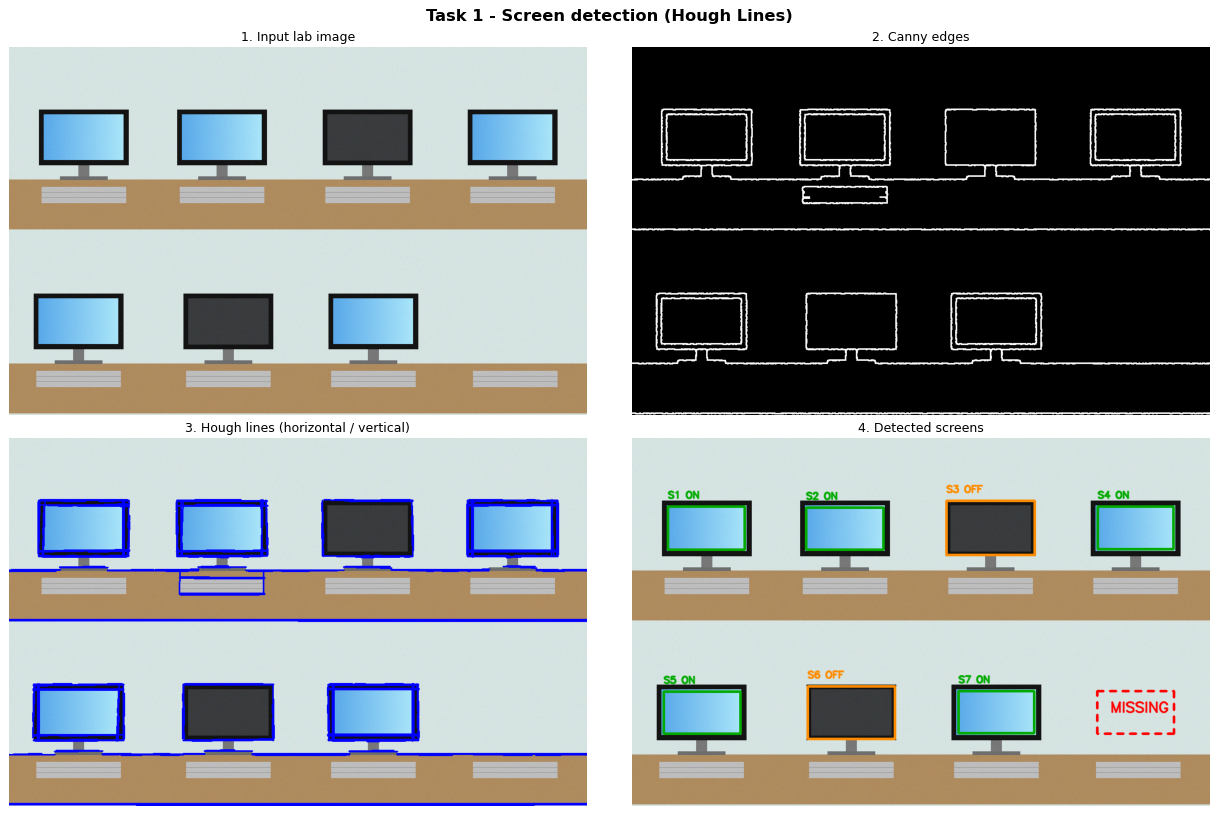

,Screen,Row,Col,Status,Mean brightness
0,S1,1,1,ON,182.5
1,S2,1,2,ON,182.7
2,S3,1,3,OFF,50.3
3,S4,1,4,ON,182.9
4,S5,2,1,ON,183.3
5,S6,2,2,OFF,51.6
6,S7,2,3,ON,182.9


Detected 7 screens -> ON: 5, OFF: 2, MISSING: 1
Ground truth     -> ON: 5, OFF: 2, MISSING: 1   =>  MATCH


In [3]:
LAB_IMAGE_PATH = None          # e.g. "my_lab.jpg"  (None -> synthetic lab)

def make_lab_image(w=1100, h=700, rows=2, cols=4, off=((0, 2), (1, 1)), missing=((1, 3),), seed=3):
    r = np.random.default_rng(seed)
    img = np.full((h, w, 3), (226, 228, 214), np.uint8)               # wall
    cw, ch = w // cols, h // rows
    truth = {}
    for rr in range(rows):
        top = rr * ch
        desk_y = top + int(ch * 0.72)
        cv2.rectangle(img, (0, desk_y), (w, top + ch - 4), (95, 140, 175), -1)            # desk
        for cc in range(cols):
            cx = cc * cw + cw // 2 + int(r.integers(-8, 9))
            # keyboard + stand are drawn for every seat
            cv2.rectangle(img, (cx - 80, desk_y + 14), (cx + 80, desk_y + 44), (190, 190, 190), -1)
            for k in range(1, 3):
                cv2.line(img, (cx - 80, desk_y + 14 + k * 10), (cx + 80, desk_y + 14 + k * 10), (150, 150, 150), 1)
            if (rr, cc) in missing:
                truth[(rr, cc)] = "MISSING"
                continue
            mw, mh, b = 170, 105, 9
            mt = desk_y - mh - 28
            cv2.rectangle(img, (cx - 10, mt + mh), (cx + 10, desk_y), (120, 120, 120), -1)    # stand
            cv2.rectangle(img, (cx - 45, desk_y - 6), (cx + 45, desk_y), (110, 110, 110), -1)  # base
            cv2.rectangle(img, (cx - mw // 2, mt), (cx + mw // 2, mt + mh), (20, 20, 20), -1)  # bezel
            x0, y0, x1, y1 = cx - mw // 2 + b, mt + b, cx + mw // 2 - b, mt + mh - b
            if (rr, cc) in off:
                cv2.rectangle(img, (x0, y0), (x1, y1), (62, 60, 58), -1)
                truth[(rr, cc)] = "OFF"
            else:                                                                           # smooth wallpaper
                grad = np.linspace(0, 1, x1 - x0, dtype=np.float32)[None, :, None]
                c0, c1 = np.float32([235, 170, 90]), np.float32([250, 230, 170])
                img[y0:y1, x0:x1] = (c0 * (1 - grad) + c1 * grad).astype(np.uint8)
                truth[(rr, cc)] = "ON"
    noise = r.normal(0, 3, img.shape)
    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return img, truth

def extend_line(x1, y1, x2, y2, e):
    L = math.hypot(x2 - x1, y2 - y1) + 1e-9
    ux, uy = (x2 - x1) / L, (y2 - y1) / L
    return int(x1 - ux * e), int(y1 - uy * e), int(x2 + ux * e), int(y2 + uy * e)

def cluster_1d(vals, gap):
    order = np.argsort(vals)
    groups = [[int(order[0])]]
    for i in order[1:]:
        if vals[i] - vals[groups[-1][-1]] <= gap:
            groups[-1].append(int(i))
        else:
            groups.append([int(i)])
    return groups

def detect_screens(img, on_thresh=110):
    H_, W_ = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8))          # thicker edges -> votes are not split by noise
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=40, minLineLength=40, maxLineGap=20)
    hv = []
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            ang = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))
            if ang < 8 or ang > 172 or abs(ang - 90) < 8:          # horizontal or vertical only
                hv.append((x1, y1, x2, y2))
    line_mask = np.zeros((H_, W_), np.uint8)
    for x1, y1, x2, y2 in hv:
        ex1, ey1, ex2, ey2 = extend_line(x1, y1, x2, y2, 12)
        cv2.line(line_mask, (ex1, ey1), (ex2, ey2), 255, 3)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(cv2.bitwise_not(line_mask), connectivity=4)
    screens = []
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if 0.004 * W_ * H_ <= area <= 0.08 * W_ * H_ and 1.2 <= w / h <= 2.2 and area / float(w * h) > 0.85:
            mean_b = float(gray[y:y + h, x:x + w].mean())
            screens.append(dict(x=int(x), y=int(y), w=int(w), h=int(h), brightness=round(mean_b, 1),
                                status="ON" if mean_b > on_thresh else "OFF"))
    # ---- rows / columns and missing slots ----
    missing = []
    if screens:
        cx = np.array([s["x"] + s["w"] / 2 for s in screens]); cy = np.array([s["y"] + s["h"] / 2 for s in screens])
        mw = np.median([s["w"] for s in screens]); mh = np.median([s["h"] for s in screens])
        rg, cg = cluster_1d(cy, 0.5 * mh), cluster_1d(cx, 0.5 * mw)
        row_c = [cy[g].mean() for g in rg]; col_c = [cx[g].mean() for g in cg]
        for ri, g in enumerate(rg):
            for i in g: screens[i]["row"] = ri
        for ci, g in enumerate(cg):
            for i in g: screens[i]["col"] = ci
        have = {(s["row"], s["col"]) for s in screens}
        for ri in range(len(rg)):
            for ci in range(len(cg)):
                if (ri, ci) not in have:
                    missing.append(dict(row=ri, col=ci, x=int(col_c[ci] - mw / 2), y=int(row_c[ri] - mh / 2), w=int(mw), h=int(mh)))
    screens.sort(key=lambda s: (s["row"], s["col"]))
    return screens, missing, edges, hv

def dashed_rect(img, x, y, w, h, color, dash=12, th=2):
    for (a, b) in (((x, y), (x + w, y)), ((x + w, y), (x + w, y + h)), ((x + w, y + h), (x, y + h)), ((x, y + h), (x, y))):
        L = int(math.hypot(b[0] - a[0], b[1] - a[1])); 
        for s in range(0, L, dash * 2):
            p = (int(a[0] + (b[0] - a[0]) * s / L), int(a[1] + (b[1] - a[1]) * s / L))
            q = (int(a[0] + (b[0] - a[0]) * min(s + dash, L) / L), int(a[1] + (b[1] - a[1]) * min(s + dash, L) / L))
            cv2.line(img, p, q, color, th)

# ---------------- run Task 1 ----------------
if LAB_IMAGE_PATH and os.path.exists(LAB_IMAGE_PATH):
    lab_img, lab_truth = cv2.imread(LAB_IMAGE_PATH), None
else:
    lab_img, lab_truth = make_lab_image()
cv2.imwrite(f"{IN_DIR}/task1_lab.png", lab_img)

screens, missing, edges1, hv_lines = detect_screens(lab_img)

ann = lab_img.copy()
for i, s in enumerate(screens, 1):
    col = (0, 170, 0) if s["status"] == "ON" else (0, 140, 255)
    cv2.rectangle(ann, (s["x"], s["y"]), (s["x"] + s["w"], s["y"] + s["h"]), col, 3)
    cv2.putText(ann, f"S{i} {s['status']}", (s["x"], s["y"] - 16), cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2, cv2.LINE_AA)
for m in missing:
    dashed_rect(ann, m["x"], m["y"], m["w"], m["h"], (0, 0, 255), th=3)
    cv2.putText(ann, "MISSING", (m["x"] + 25, m["y"] + m["h"] // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2, cv2.LINE_AA)
hough_vis = lab_img.copy()
for x1, y1, x2, y2 in hv_lines:
    cv2.line(hough_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

show_grid([lab_img, edges1, hough_vis, ann],
          ["1. Input lab image", "2. Canny edges", "3. Hough lines (horizontal / vertical)", "4. Detected screens"],
          cols=2, size=(7, 4.6), suptitle="Task 1 - Screen detection (Hough Lines)")
cv2.imwrite(f"{OUT_DIR}/task1_screens.png", ann)

df1 = pd.DataFrame([{"Screen": f"S{i}", "Row": s["row"] + 1, "Col": s["col"] + 1, "Status": s["status"],
                     "Mean brightness": s["brightness"]} for i, s in enumerate(screens, 1)])
display(df1)
n_on = sum(s["status"] == "ON" for s in screens); n_off = sum(s["status"] == "OFF" for s in screens)
print(f"Detected {len(screens)} screens -> ON: {n_on}, OFF: {n_off}, MISSING: {len(missing)}")
if lab_truth:
    t_on = sum(v == "ON" for v in lab_truth.values()); t_off = sum(v == "OFF" for v in lab_truth.values())
    t_mis = sum(v == "MISSING" for v in lab_truth.values())
    ok1 = (n_on, n_off, len(missing)) == (t_on, t_off, t_mis)
    print(f"Ground truth     -> ON: {t_on}, OFF: {t_off}, MISSING: {t_mis}   =>  {'MATCH' if ok1 else 'MISMATCH'}")
    RESULTS.append(("1 Screen detection (Hough lines)", f"ON {n_on}/{t_on}, OFF {n_off}/{t_off}, missing {len(missing)}/{t_mis}", ok1))
else:
    RESULTS.append(("1 Screen detection (Hough lines)", f"ON {n_on}, OFF {n_off}, missing {len(missing)}", True))

---
## Task 2 – Asset Tracking in a Computer Lab using SIFT

**Goal:** automatically recognise individual computer components (monitor, keyboard, PC tower, mouse) in a lab scene and build an **inventory**.

**Input needed:** one *reference image per component* (template) + one *scene photo*. *Generated here:* 4 textured component templates and a scene that contains **2 monitors, 2 keyboards, 1 tower, 1 mouse**, placed at different scales / rotations / slight perspective. *Your own data:* set `TEMPLATE_PATHS` (dict `name -> file`) and `ASSET_SCENE_PATH`.

**Method**
1. Detect SIFT key-points + descriptors on every template and on the scene.
2. Match scene → template descriptors (`BFMatcher`, kNN k = 2) and keep matches passing **Lowe's ratio test** (0.75).
3. **RANSAC homography** on the matches → the template's outline in the scene. Inliers are removed and the step repeats, so the **same item appearing several times is counted several times**.
4. Sanity-check each outline (convex, sensible size, not a duplicate) and draw it with a label.
5. Count detections per class → inventory table (compared with ground truth for the synthetic scene).

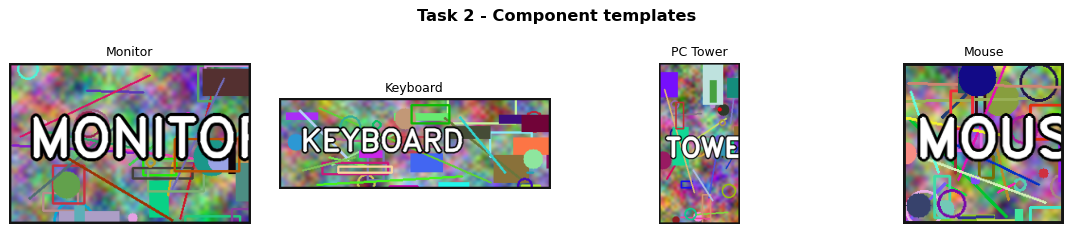

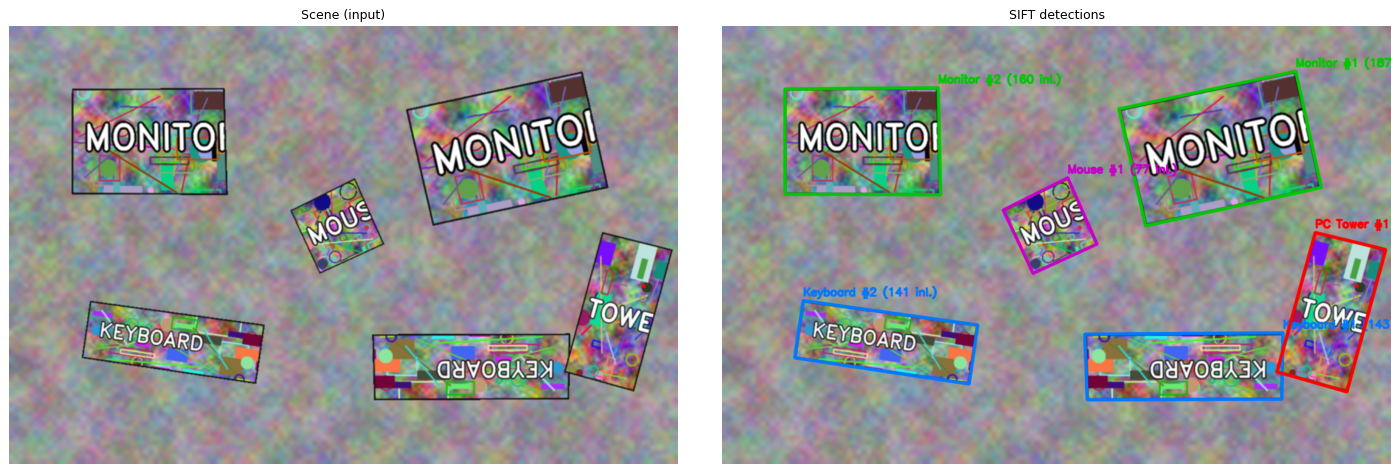

,Item,Detected,Template_keypoints,Expected
0,Monitor,2,399,2
1,Keyboard,2,361,2
2,PC Tower,1,277,1
3,Mouse,1,297,1


Scene key-points: 3195 | Total assets found: 6
Inventory vs ground truth: MATCH


In [4]:
TEMPLATE_PATHS  = None     # e.g. {"Monitor": "monitor.jpg", "Keyboard": "kb.jpg"}  (None -> synthetic)
ASSET_SCENE_PATH = None    # e.g. "lab_scene.jpg"

sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

def find_instances(tpl_img, tpl_kp, tpl_des, scene_kp, scene_des, ratio=0.75, min_inliers=10, max_inst=8, ransac_thr=4.0):
    """Find every instance of a template inside a scene (SIFT + ratio test + iterative RANSAC homography)."""
    h, w = tpl_img.shape[:2]
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    if tpl_des is None or scene_des is None or len(tpl_des) < 2 or len(scene_des) < 2:
        return []
    knn = bf.knnMatch(scene_des, tpl_des, k=2)                 # scene -> template keeps repeated objects matchable
    cand = np.array([(m.queryIdx, m.trainIdx) for m, n in knn if m.distance < ratio * n.distance])
    found = []
    while len(cand) >= min_inliers and len(found) < max_inst:
        src = np.float32([tpl_kp[t].pt for s, t in cand]).reshape(-1, 1, 2)
        dst = np.float32([scene_kp[s].pt for s, t in cand]).reshape(-1, 1, 2)
        Hm, mask = cv2.findHomography(src, dst, cv2.RANSAC, ransac_thr)
        if Hm is None:
            break
        inl = mask.ravel().astype(bool)
        if inl.sum() < min_inliers:
            break
        quad = cv2.perspectiveTransform(corners, Hm).reshape(-1, 2)
        cand = cand[~inl]                                       # remove explained matches -> look for the next copy
        if not poly_ok(quad, w * h):
            continue
        centre = quad.mean(0)
        diag = math.sqrt(cv2.contourArea(quad.astype(np.float32)))
        if any(np.linalg.norm(centre - f["quad"].mean(0)) < 0.3 * diag for f in found):
            continue                                            # duplicate of an already found instance
        found.append(dict(quad=quad, inliers=int(inl.sum())))
    return found

# ---------- inputs ----------
if TEMPLATE_PATHS and ASSET_SCENE_PATH and os.path.exists(ASSET_SCENE_PATH):
    templates = {k: cv2.imread(v) for k, v in TEMPLATE_PATHS.items()}
    scene2 = cv2.imread(ASSET_SCENE_PATH); truth2 = None
else:
    spec = {"Monitor": (300, 200, 101, "MONITOR"), "Keyboard": (360, 120, 102, "KEYBOARD"),
            "PC Tower": (150, 300, 103, "TOWER"),  "Mouse": (170, 170, 104, "MOUSE")}
    templates = {k: textured_patch(w, h, s, lab) for k, (w, h, s, lab) in spec.items()}
    scene2 = textured_background(1100, 720, seed=77, contrast=0.35, base=(150, 150, 150))
    plan = [("Monitor", (230, 190), 0.85, 0), ("Monitor", (820, 200), 1.0, -12), ("Keyboard", (270, 520), 0.8, 8),
            ("Keyboard", (760, 560), 0.9, 180), ("PC Tower", (1000, 470), 0.8, 15), ("Mouse", (540, 330), 0.7, -25)]
    truth2 = {}
    for i, (name, c, sc, an) in enumerate(plan):
        paste_patch(scene2, templates[name], c, sc, an, jitter=0.02, seed=i)
        truth2[name] = truth2.get(name, 0) + 1
    scene2 = cv2.GaussianBlur(scene2, (3, 3), 0)
    for k, v in templates.items():
        cv2.imwrite(f"{IN_DIR}/task2_template_{k.replace(' ', '_').lower()}.png", v)
    cv2.imwrite(f"{IN_DIR}/task2_scene.png", scene2)

# ---------- detection ----------
sg = cv2.cvtColor(scene2, cv2.COLOR_BGR2GRAY)
s_kp, s_des = sift.detectAndCompute(sg, None)
palette = [(0, 200, 0), (255, 120, 0), (0, 0, 255), (200, 0, 200), (0, 200, 200), (120, 120, 0)]
vis2 = scene2.copy()
inventory = []
for ci, (name, tpl) in enumerate(templates.items()):
    t_kp, t_des = sift.detectAndCompute(cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY), None)
    inst = find_instances(tpl, t_kp, t_des, s_kp, s_des)
    col = palette[ci % len(palette)]
    for j, f in enumerate(inst, 1):
        q = f["quad"].astype(np.int32)
        cv2.polylines(vis2, [q], True, col, 4, cv2.LINE_AA)
        p = q[q[:, 1].argmin()]
        cv2.putText(vis2, f"{name} #{j} ({f['inliers']} inl.)", (int(p[0]), max(18, int(p[1]) - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2, cv2.LINE_AA)
    inventory.append(dict(Item=name, Detected=len(inst), Template_keypoints=len(t_kp),
                          Expected=(truth2.get(name, 0) if truth2 else "-")))

show_grid(list(templates.values()), list(templates.keys()), cols=4, size=(3.2, 2.6), suptitle="Task 2 - Component templates")
show_grid([scene2, vis2], ["Scene (input)", "SIFT detections"], cols=2, size=(8, 5.2))
cv2.imwrite(f"{OUT_DIR}/task2_inventory.png", vis2)
df2 = pd.DataFrame(inventory)
display(df2)
print("Scene key-points:", len(s_kp), "| Total assets found:", int(df2["Detected"].sum()))
if truth2:
    ok2 = all(r_["Detected"] == r_["Expected"] for r_ in inventory)
    print("Inventory vs ground truth:", "MATCH" if ok2 else "MISMATCH")
    RESULTS.append(("2 Asset tracking (SIFT)", f"{int(df2['Detected'].sum())}/{sum(truth2.values())} assets found", ok2))
else:
    RESULTS.append(("2 Asset tracking (SIFT)", f"{int(df2['Detected'].sum())} assets found", True))

---
## Task 3 – Anomaly Detection in Sensor Data using Wavelet Transformation

**Goal:** monitor machine sensor data and flag abnormal readings, using wavelet analysis.

**Input needed:** a 1-D sensor signal. *Generated here:* 1000 samples = slow drift (sine) + Gaussian noise + 8 injected faults (spikes / dips) at known positions. *Your own data:* set `SENSOR_CSV` (one column of numbers).

**Method**
1. **Discrete Wavelet Transform** (`db4`, 5 levels) → approximation + detail coefficients.
2. Noise level from the finest details: σ = MAD / 0.6745. **Universal threshold** `σ·√(2 ln n)`; **soft-threshold** the detail coefficients.
3. **Inverse DWT** → *denoised signal* (the normal behaviour).
4. **Residual** = sensor data − denoised signal.
5. **Anomaly** = residual deviating more than `K × robust σ` (MAD-based) from its median.

**Expected output:** two plots exactly like the lab sheet – *Sensor Data and Denoised Signal* and *Residuals and Detected Anomalies* (green dots).
Tip: `K = 2` flags many more points and gives the dense-dot look of the sample figure; `K = 3.5` flags only real faults.

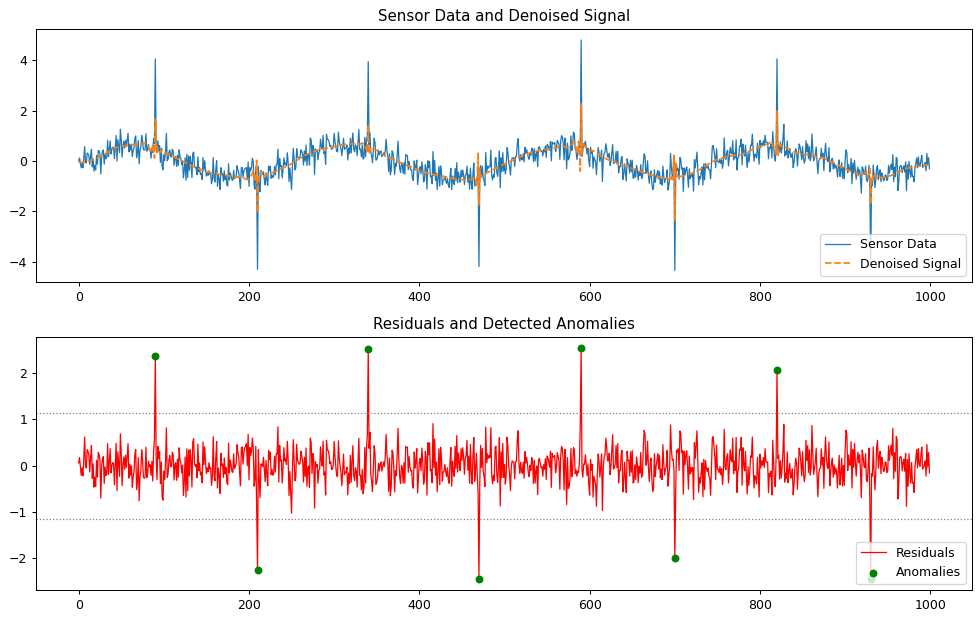

Noise sigma (wavelet) = 0.333 | universal threshold = 1.237 | anomaly threshold = +/-1.155
Anomalies detected: 8 -> indices [90, 210, 340, 470, 590, 700, 820, 930]
Injected faults: [90, 210, 340, 470, 590, 700, 820, 930]
Recall = 1.00 | Precision = 1.00


In [5]:
SENSOR_CSV = None          # e.g. "sensor.csv"  (None -> synthetic sensor)
WAVELET, LEVEL, K = "db4", 5, 3.5

if SENSOR_CSV and os.path.exists(SENSOR_CSV):
    sig = pd.read_csv(SENSOR_CSV).iloc[:, 0].to_numpy(float); true_idx = None
else:
    rs_ = np.random.default_rng(7)
    n = 1000; t = np.arange(n)
    sig = 0.6 * np.sin(2 * np.pi * t / 250) + rs_.normal(0, 0.35, n)
    true_idx = np.array([90, 210, 340, 470, 590, 700, 820, 930])
    sig[true_idx] += np.array([3.6, -3.8, 3.4, -3.5, 4.0, -3.7, 3.5, -4.0])
    pd.DataFrame({"sensor": sig}).to_csv(f"{IN_DIR}/task3_sensor.csv", index=False)
n = len(sig)

# 1-2. decompose + threshold the detail coefficients
coeffs = pywt.wavedec(sig, WAVELET, level=LEVEL)
sigma_noise = np.median(np.abs(coeffs[-1])) / 0.6745
uthr = sigma_noise * np.sqrt(2 * np.log(n))
den_coeffs = [coeffs[0]] + [pywt.threshold(c, uthr, mode="soft") for c in coeffs[1:]]
# 3. reconstruct
denoised = pywt.waverec(den_coeffs, WAVELET)[:n]
# 4-5. residual + anomaly rule
resid = sig - denoised
med = np.median(resid)
rob_sigma = 1.4826 * np.median(np.abs(resid - med))
thr = K * rob_sigma
anom_idx = np.where(np.abs(resid - med) > thr)[0]

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(sig, label="Sensor Data", lw=1)
ax[0].plot(denoised, "--", label="Denoised Signal", lw=1.4)
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")
ax[1].plot(resid, color="red", lw=1, label="Residuals")
ax[1].scatter(anom_idx, resid[anom_idx], color="green", zorder=3, s=28, label="Anomalies")
ax[1].axhline(med + thr, color="gray", ls=":", lw=1); ax[1].axhline(med - thr, color="gray", ls=":", lw=1)
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/task3_wavelet_anomalies.png"); plt.show()

print(f"Noise sigma (wavelet) = {sigma_noise:.3f} | universal threshold = {uthr:.3f} | anomaly threshold = +/-{thr:.3f}")
print(f"Anomalies detected: {len(anom_idx)} -> indices {anom_idx.tolist()}")
if true_idx is not None:
    hit = [int(i) for i in true_idx if np.any(np.abs(anom_idx - i) <= 1)]
    tp = sum(np.any(np.abs(true_idx - a) <= 1) for a in anom_idx)
    prec = tp / max(len(anom_idx), 1); rec = len(hit) / len(true_idx)
    print(f"Injected faults: {true_idx.tolist()}\nRecall = {rec:.2f} | Precision = {prec:.2f}")
    RESULTS.append(("3 Wavelet anomaly detection", f"recall {rec:.2f}, precision {prec:.2f} ({len(anom_idx)} flagged)", rec == 1.0 and prec >= 0.8))
else:
    RESULTS.append(("3 Wavelet anomaly detection", f"{len(anom_idx)} anomalies flagged", True))

---
# PART B – Lab tasks
## Task 4 – Object Recognition (using Video) with SIFT

**Goal:** recognise and locate a reference object in a video, even when it changes **scale**, **orientation**, is **partially occluded**, or **leaves the scene**; draw bounding boxes.

**Input needed:** a *reference image* of the object + a *video*. *Generated here:* a 90-frame video (`task4_video.avi`) where the object moves, scales 0.75→1.25→0.75, rotates −25°→+25°, is **partly covered by a dark block (frames 36-50)** and **disappears (frames 62-71)** to test false positives. *Your own data:* set `REF_IMAGE_PATH` and `OBJ_VIDEO_PATH`.

**Method (per frame)**
1. SIFT on the frame → match against the reference's SIFT descriptors (kNN + **Lowe ratio test 0.75**).
2. ≥ 12 good matches → **RANSAC homography** → project the reference corners into the frame.
3. Accept only if inliers ≥ 12 and the quadrilateral is convex with a plausible area. Draw the **oriented box (green)** and the **axis-aligned bounding box (yellow)**.
4. Save the annotated video (`task4_output.avi`) and report recall / false positives / localisation error.

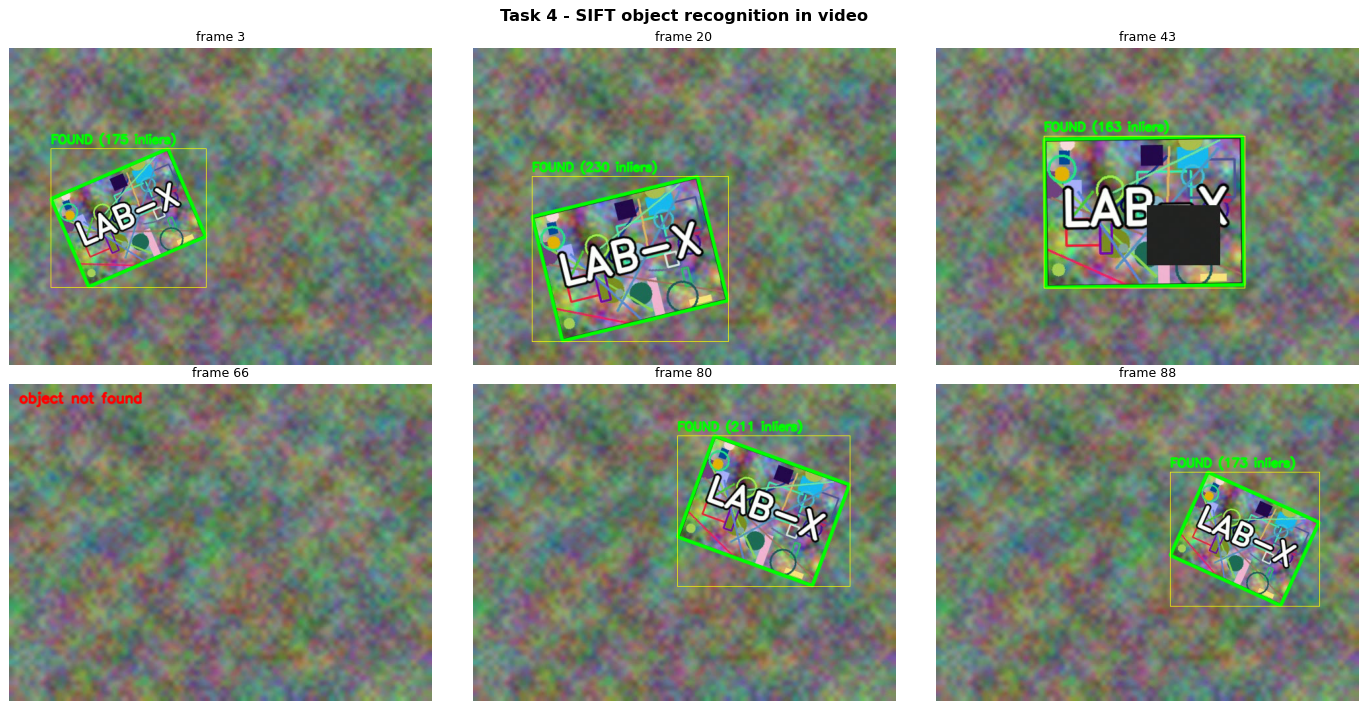

Frames: 90 | object present in 80
Recognised: 80/80 (100.0 %) | missed: 0 | false positives (object absent): 0
Mean centre error: 0.12 px | max: 0.31 px
Annotated video saved -> lab06_outputs/task4_output.avi


In [6]:
REF_IMAGE_PATH, OBJ_VIDEO_PATH = None, None     # None -> synthetic reference + video

W4, H4, N4 = 640, 480, 90
if REF_IMAGE_PATH and OBJ_VIDEO_PATH and os.path.exists(OBJ_VIDEO_PATH):
    ref4 = cv2.imread(REF_IMAGE_PATH)
    frames4 = read_video(OBJ_VIDEO_PATH); gt4 = None
else:
    ref4 = textured_patch(240, 180, seed=11, label="LAB-X")
    bg4 = textured_background(W4, H4, seed=21, contrast=0.5, base=(110, 125, 115))
    rn = np.random.default_rng(5)
    frames4, gt4 = [], []
    for k in range(N4):
        t = k / (N4 - 1)
        fr = bg4.copy()
        cx, cy = 170 + 300 * t, 240 + 80 * np.sin(2 * np.pi * t)
        sc, ang = 0.75 + 0.5 * np.sin(np.pi * t), -25 + 50 * t
        present = not (62 <= k <= 71)
        quad = None
        if present:
            quad = paste_patch(fr, ref4, (cx, cy), sc, ang)
            if 36 <= k <= 50:                                        # partial occlusion (~25 % of the object)
                cv2.rectangle(fr, (int(cx + 5), int(cy - 10)), (int(cx + 115), int(cy + 80)), (35, 35, 35), -1)
        fr = np.clip(fr.astype(np.float32) + rn.normal(0, 2, fr.shape), 0, 255).astype(np.uint8)
        frames4.append(fr); gt4.append(quad)
    cv2.imwrite(f"{IN_DIR}/task4_reference.png", ref4)
    write_video(f"{IN_DIR}/task4_video.avi", frames4, fps=20)
    frames4 = read_video(f"{IN_DIR}/task4_video.avi", fallback=frames4)    # read back like a real video file

sift4, bf4 = cv2.SIFT_create(), cv2.BFMatcher(cv2.NORM_L2)
kp_r, des_r = sift4.detectAndCompute(cv2.cvtColor(ref4, cv2.COLOR_BGR2GRAY), None)
rh, rw = ref4.shape[:2]
ref_corners = np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2)

def recognise(frame, ratio=0.75, min_inl=12):
    kp, des = sift4.detectAndCompute(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None)
    if des is None or len(kp) < 5:
        return None, 0
    knn = bf4.knnMatch(des_r, des, k=2)
    good = [m for m, n_ in knn if m.distance < ratio * n_.distance]
    if len(good) < min_inl:
        return None, len(good)
    src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    Hm, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    if Hm is None or int(mask.sum()) < min_inl:
        return None, 0
    quad = cv2.perspectiveTransform(ref_corners, Hm).reshape(-1, 2)
    if not poly_ok(quad, rw * rh, 0.2, 3.5):
        return None, 0
    return quad, int(mask.sum())

out4, hits, errs, fp, miss = [], 0, [], 0, 0
n_present = sum(g is not None for g in gt4) if gt4 else None
for k, fr in enumerate(frames4):
    quad, inl = recognise(fr)
    vis = fr.copy()
    if quad is not None:
        cv2.polylines(vis, [quad.astype(np.int32)], True, (0, 255, 0), 3, cv2.LINE_AA)
        x, y, w_, h_ = cv2.boundingRect(quad.astype(np.float32))
        cv2.rectangle(vis, (x, y), (x + w_, y + h_), (0, 255, 255), 1)
        cv2.putText(vis, f"FOUND ({inl} inliers)", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
    else:
        cv2.putText(vis, "object not found", (15, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
    if gt4:
        g = gt4[k]
        if g is not None and quad is not None:
            hits += 1; errs.append(float(np.linalg.norm(quad.mean(0) - g.mean(0))))
        elif g is not None:
            miss += 1
        elif quad is not None:
            fp += 1
    out4.append(vis)
write_video(f"{OUT_DIR}/task4_output.avi", out4, fps=20)

pick = [3, 20, 43, 66, 80, 88] if len(out4) > 88 else list(np.linspace(0, len(out4) - 1, 6).astype(int))
show_grid([out4[i] for i in pick], [f"frame {i}" for i in pick], cols=3, size=(5.2, 4), suptitle="Task 4 - SIFT object recognition in video")
if gt4:
    print(f"Frames: {len(frames4)} | object present in {n_present}")
    print(f"Recognised: {hits}/{n_present} ({100 * hits / n_present:.1f} %) | missed: {miss} | false positives (object absent): {fp}")
    print(f"Mean centre error: {np.mean(errs):.2f} px | max: {np.max(errs):.2f} px")
    RESULTS.append(("4 Object recognition (SIFT video)", f"recall {hits}/{n_present}, false positives {fp}, centre err {np.mean(errs):.1f}px", hits / n_present >= 0.95 and fp == 0))
else:
    print("Frames processed:", len(frames4))
    RESULTS.append(("4 Object recognition (SIFT video)", f"{len(frames4)} frames processed", True))
print("Annotated video saved ->", f"{OUT_DIR}/task4_output.avi")

---
## Task 5 – Your Panoramic Image (SIFT stitching)

**Goal:** stitch several overlapping photos taken while panning into **one panorama**.

**Input needed:** an ordered set of overlapping images (≈ 30-40 % overlap). *Generated here:* 5 shots cut from a large scene with ~35 % overlap, small vertical shifts, slight rotation and exposure changes. *Your own data:* set `PANO_PATHS` (list of files, left → right).

**Method**
1. SIFT key-points on every image; match each **adjacent pair** (ratio test 0.75).
2. **RANSAC homography** for each pair.
3. Chain the homographies so every image maps into the coordinate system of the **middle image** (least distortion).
4. Compute the canvas size from the warped corners, `warpPerspective` every image onto it.
5. **Feather blending** (distance-transform weights) hides seams and exposure differences.
6. Crop the black borders.

**Expected output:** inlier matches for the first pair, then the final panorama.

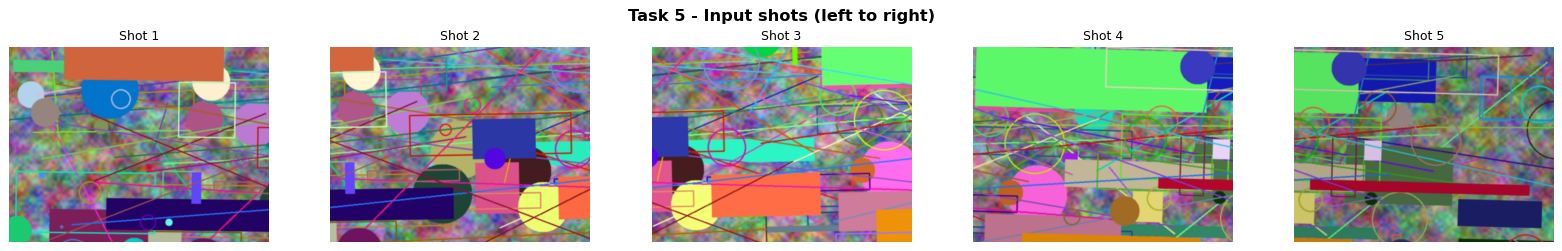

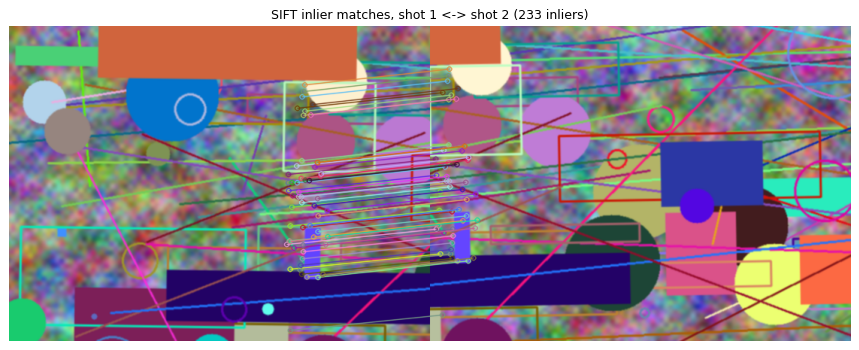

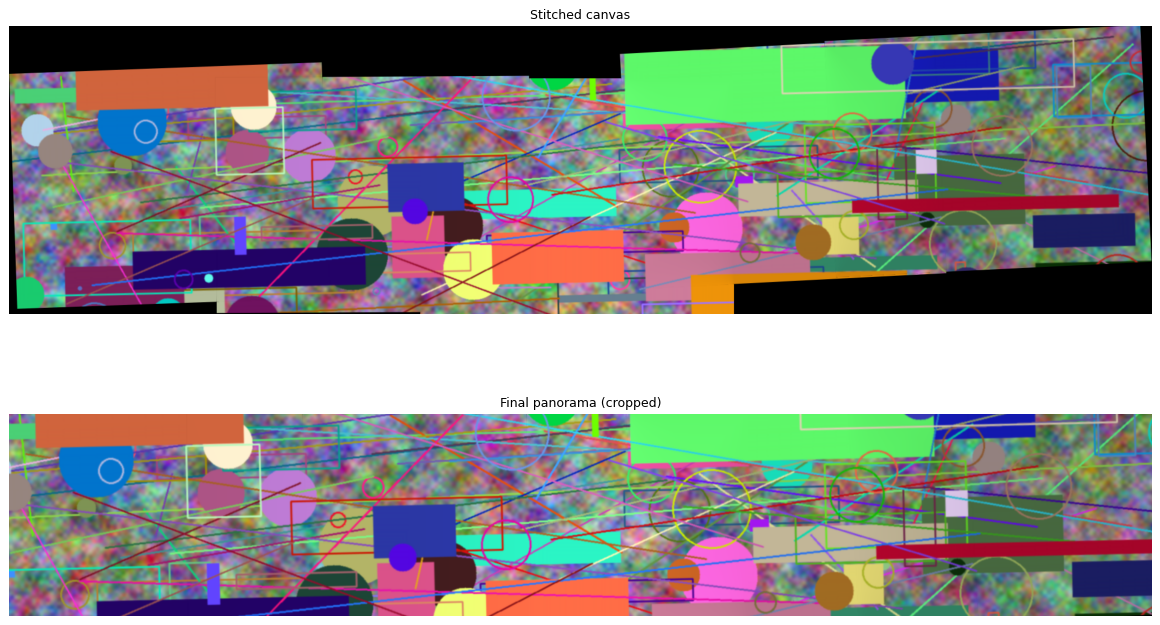

5 images (560x420 each) -> panorama 1883x333


In [7]:
PANO_PATHS = None          # e.g. ["p1.jpg", "p2.jpg", "p3.jpg"] (None -> synthetic shots)

if PANO_PATHS and all(os.path.exists(p) for p in PANO_PATHS):
    shots = [cv2.imread(p) for p in PANO_PATHS]
else:
    big = textured_patch(2100, 520, seed=205, n_shapes=190)
    big = cv2.GaussianBlur(big, (3, 3), 0)
    rp = np.random.default_rng(9)
    shots, SW, SH = [], 560, 420
    for i in range(5):
        x0 = i * 365 + 20
        dy, rot = rp.integers(-18, 19), rp.uniform(-1.8, 1.8)
        M = cv2.getRotationMatrix2D((SW / 2, SH / 2), rot, 1.0)
        M[0, 2] += -x0; M[1, 2] += -(50 + dy)
        sh = cv2.warpAffine(big, M, (SW, SH), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        sh = np.clip(sh.astype(np.float32) * rp.uniform(0.9, 1.1), 0, 255).astype(np.uint8)    # exposure change
        shots.append(sh)
        cv2.imwrite(f"{IN_DIR}/task5_pano_{i + 1}.jpg", sh)

sift5, bf5 = cv2.SIFT_create(), cv2.BFMatcher(cv2.NORM_L2)

def match_pair(a, b, ratio=0.75):
    """Homography mapping image a -> image b (+ key-points and inlier matches for drawing)."""
    kpa, da = sift5.detectAndCompute(cv2.cvtColor(a, cv2.COLOR_BGR2GRAY), None)
    kpb, db = sift5.detectAndCompute(cv2.cvtColor(b, cv2.COLOR_BGR2GRAY), None)
    knn = bf5.knnMatch(da, db, k=2)
    good = [m for m, n_ in knn if m.distance < ratio * n_.distance]
    if len(good) < 10:
        raise RuntimeError("Not enough matches - are the images overlapping and in order?")
    pa = np.float32([kpa[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    pb = np.float32([kpb[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    Hm, mask = cv2.findHomography(pa, pb, cv2.RANSAC, 4.0)
    inl = [m for m, k in zip(good, mask.ravel()) if k]
    return Hm, kpa, kpb, inl

def crop_black(valid, tol=0.02):
    ys, xs = np.where(valid)
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    while y1 - y0 > 2 and x1 - x0 > 2:
        ch = False
        if (~valid[y0, x0:x1]).mean() > tol: y0 += 1; ch = True
        if (~valid[y1 - 1, x0:x1]).mean() > tol: y1 -= 1; ch = True
        if (~valid[y0:y1, x0]).mean() > tol: x0 += 1; ch = True
        if (~valid[y0:y1, x1 - 1]).mean() > tol: x1 -= 1; ch = True
        if not ch:
            break
    return y0, y1, x0, x1

def stitch(imgs):
    n_ = len(imgs); mid = n_ // 2
    to_ref = [None] * n_; to_ref[mid] = np.eye(3)
    for i in range(mid - 1, -1, -1):                       # left of reference
        Hm = match_pair(imgs[i], imgs[i + 1])[0]; to_ref[i] = to_ref[i + 1] @ Hm
    for i in range(mid + 1, n_):                           # right of reference
        Hm = match_pair(imgs[i], imgs[i - 1])[0]; to_ref[i] = to_ref[i - 1] @ Hm
    allc = []
    for im, Hm in zip(imgs, to_ref):
        h, w = im.shape[:2]
        c = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        allc.append(cv2.perspectiveTransform(c, Hm).reshape(-1, 2))
    allc = np.vstack(allc)
    mn, mx = np.floor(allc.min(0)).astype(int), np.ceil(allc.max(0)).astype(int)
    W_, H_ = int(mx[0] - mn[0]), int(mx[1] - mn[1])
    if W_ * H_ > 60_000_000:
        raise RuntimeError("Canvas too large - homographies are unstable.")
    T = np.array([[1, 0, -mn[0]], [0, 1, -mn[1]], [0, 0, 1]], np.float64)
    acc = np.zeros((H_, W_, 3), np.float32); wsum = np.zeros((H_, W_), np.float32)
    for im, Hm in zip(imgs, to_ref):
        M = T @ Hm
        warped = cv2.warpPerspective(im, M, (W_, H_)).astype(np.float32)
        mask = cv2.warpPerspective(np.full(im.shape[:2], 255, np.uint8), M, (W_, H_)) > 0
        dist = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 3)
        acc += warped * dist[..., None]; wsum += dist
    pano_full = (acc / np.maximum(wsum, 1e-6)[..., None]).astype(np.uint8)
    y0, y1, x0, x1 = crop_black(wsum > 0)
    return pano_full, pano_full[y0:y1, x0:x1]

H01, k0, k1, inl01 = match_pair(shots[0], shots[1])
match_vis = cv2.drawMatches(shots[0], k0, shots[1], k1, inl01[:60], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
pano_full, pano = stitch(shots)
cv2.imwrite(f"{OUT_DIR}/task5_panorama.jpg", pano)

show_grid(shots, [f"Shot {i + 1}" for i in range(len(shots))], cols=5, size=(3.6, 2.8), suptitle="Task 5 - Input shots (left to right)")
show_grid([match_vis], [f"SIFT inlier matches, shot 1 <-> shot 2 ({len(inl01)} inliers)"], cols=1, size=(12, 4))
show_grid([pano_full, pano], ["Stitched canvas", "Final panorama (cropped)"], cols=1, size=(13, 4.2))
print(f"{len(shots)} images ({shots[0].shape[1]}x{shots[0].shape[0]} each) -> panorama {pano.shape[1]}x{pano.shape[0]}")
RESULTS.append(("5 Panorama (SIFT stitching)", f"{len(shots)} images -> {pano.shape[1]}x{pano.shape[0]} px", pano.shape[1] > shots[0].shape[1] * 2.5))

---
## Task 6 – Lane Detection using the Hough Line Transform

**Goal:** detect lane markings in road images from a vehicle camera and draw the lane lines for lane-keeping.

**Input needed:** road images from a front camera. *Generated here:* 3 road scenes – (a) straight with solid lines, (b) shifted vanishing point + **dashed** right line, (c) dim light + **shadow band** + noise. *Your own data:* set `LANE_PATHS` (list of image files).

**Method**
1. Grayscale → Gaussian blur → **Canny**.
2. **Region of interest** – keep only the trapezoid in front of the car (ignores sky, trees).
3. **`cv2.HoughLinesP`** (with a large `maxLineGap` so dashed lines are bridged).
4. Split segments by **slope** (negative = left lane, positive = right lane; near-horizontal ones are discarded).
5. **Weighted line fit** per side and extrapolation from the bottom of the image up to the horizon.
6. Draw lane lines (red) + translucent lane area (green).

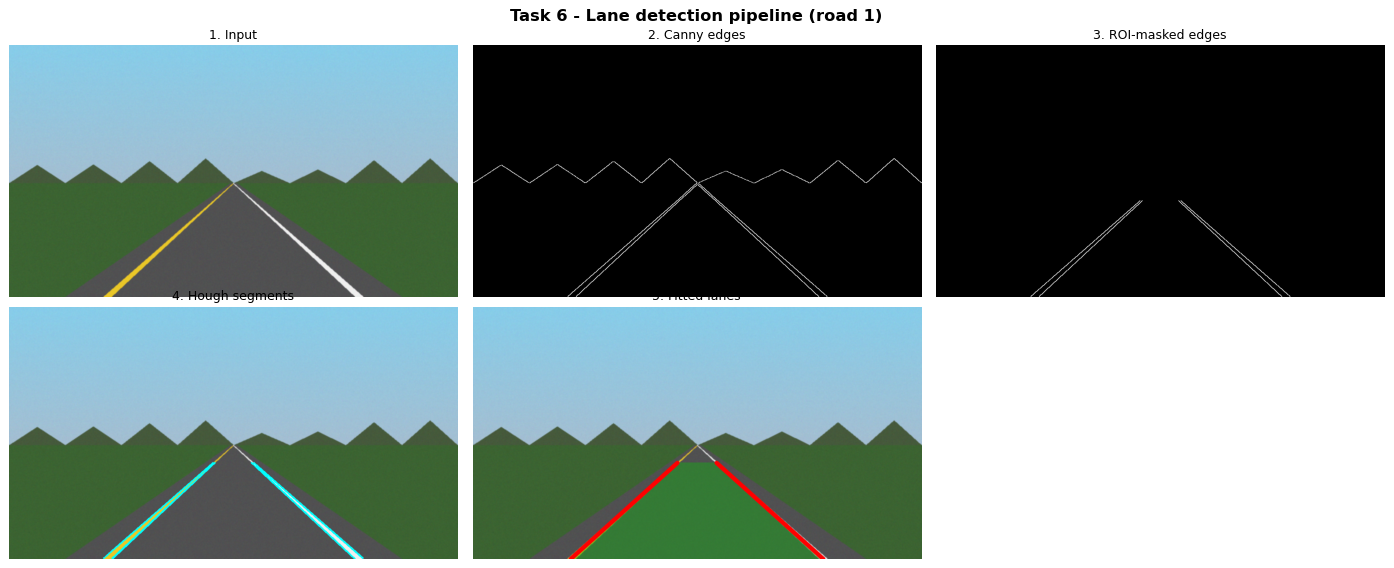

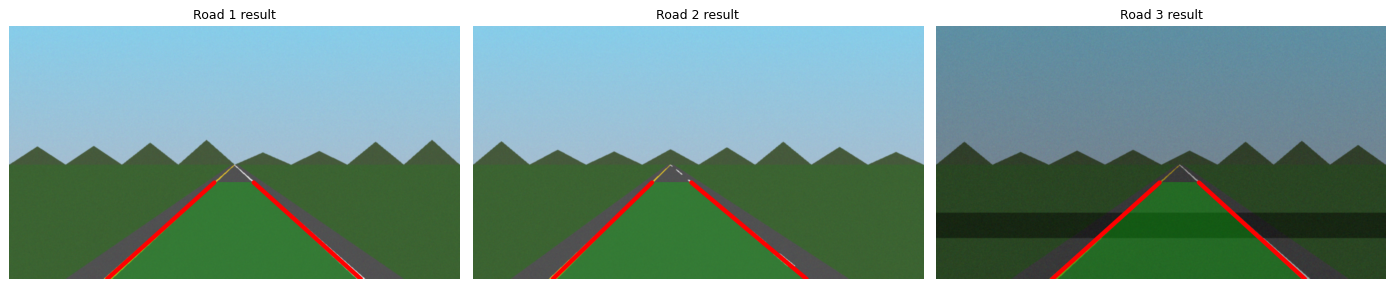

,Image,Left lane,Right lane,Left x-error (px),Right x-error (px)
0,1,found,found,2,1
1,2,found,found,1,0
2,3,found,found,3,3


In [8]:
LANE_PATHS = None           # e.g. ["road1.jpg", "road2.jpg"]  (None -> synthetic roads)

def make_road(w=960, h=540, vx=480, xc=480, lane_half=270, right_style="solid", shadow=False, dark=1.0, seed=0):
    r = np.random.default_rng(seed)
    yh = int(h * 0.55)
    img = np.zeros((h, w, 3), np.uint8)
    for y in range(yh):                                                   # sky
        tt = y / yh; img[y, :] = (int(235 - 25 * tt), int(206 - 15 * tt), int(135 + 30 * tt))
    for hx in range(0, w, 120):                                           # distant hills (above the ROI)
        cv2.fillPoly(img, [np.array([[hx, yh], [hx + 60, yh - int(r.integers(25, 55))], [hx + 120, yh]])], (60, 90, 70))
    cv2.rectangle(img, (0, yh), (w, h), (50, 100, 60), -1)                # grass (same luminance as the road)
    cv2.fillPoly(img, [np.array([[xc - lane_half - 90, h], [xc + lane_half + 90, h], [vx + 7, yh], [vx - 7, yh]], np.int32)], (82, 81, 81))

    def mark(x_b, color, hw_b, t0, t1):
        def xy(t):
            y = yh + (h - yh) * t
            return vx + (x_b - vx) * t, y, hw_b * t + 0.5
        (xa, ya, wa), (xb, yb, wb) = xy(t0), xy(t1)
        cv2.fillPoly(img, [np.array([[xa - wa, ya], [xa + wa, ya], [xb + wb, yb], [xb - wb, yb]], np.float32).astype(np.int32)], color)

    mark(xc - lane_half, (40, 200, 235), 8, 0.0, 1.0)                     # left: solid yellow
    if right_style == "solid":
        mark(xc + lane_half, (240, 240, 240), 8, 0.0, 1.0)
    else:                                                                 # right: dashed white
        edges = (np.arange(0, 15) / 14.0) ** 1.6
        for i in range(0, 14, 2):
            mark(xc + lane_half, (240, 240, 240), 8, edges[i], edges[i + 1])
    if shadow:                                                            # horizontal shadow band on the road
        ov = img.astype(np.float32); ov[int(h * 0.74):int(h * 0.84), :] *= 0.55; img = ov.astype(np.uint8)
    img = np.clip(img.astype(np.float32) * dark + r.normal(0, 4 if not shadow else 6, img.shape), 0, 255).astype(np.uint8)
    return cv2.GaussianBlur(img, (3, 3), 0), (xc - lane_half, xc + lane_half)

def detect_lanes(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    roi = np.zeros_like(edges)
    cv2.fillPoly(roi, [np.array([[(int(.05 * w), h), (int(.35 * w), int(.62 * h)), (int(.65 * w), int(.62 * h)), (int(.95 * w), h)]], np.int32)], 255)
    masked = cv2.bitwise_and(edges, roi)
    segs = cv2.HoughLinesP(masked, 1, np.pi / 180, threshold=30, minLineLength=40, maxLineGap=150)
    left, right, raw = [], [], []
    if segs is not None:
        for x1, y1, x2, y2 in segs[:, 0]:
            raw.append((x1, y1, x2, y2))
            if x2 == x1: continue
            m = (y2 - y1) / (x2 - x1)
            if abs(m) < 0.4 or abs(m) > 6: continue                      # drop near-horizontal / near-vertical noise
            L = math.hypot(x2 - x1, y2 - y1)
            if m < 0 and (x1 + x2) / 2 < 0.6 * w: left.append((x1, y1, x2, y2, L))
            elif m > 0 and (x1 + x2) / 2 > 0.4 * w: right.append((x1, y1, x2, y2, L))
    y_top = int(0.62 * h)
    def fit(side):
        if len(side) == 0: return None
        ys = np.array([[s[1], s[3]] for s in side]).ravel(); xs = np.array([[s[0], s[2]] for s in side]).ravel()
        ws = np.array([[s[4], s[4]] for s in side]).ravel()
        a, b = np.polyfit(ys, xs, 1, w=ws)                                # x = a*y + b
        return (int(a * h + b), h, int(a * y_top + b), y_top)
    L_, R_ = fit(left), fit(right)
    out = img.copy(); lane_layer = img.copy()
    if L_ and R_:
        cv2.fillPoly(lane_layer, [np.array([[L_[0], L_[1]], [L_[2], L_[3]], [R_[2], R_[3]], [R_[0], R_[1]]], np.int32)], (0, 200, 0))
        out = cv2.addWeighted(lane_layer, 0.35, img, 0.65, 0)
    for ln in (L_, R_):
        if ln: cv2.line(out, (ln[0], ln[1]), (ln[2], ln[3]), (0, 0, 255), 7, cv2.LINE_AA)
    return out, L_, R_, edges, masked, raw

if LANE_PATHS and all(os.path.exists(p) for p in LANE_PATHS):
    roads = [(cv2.imread(p), None) for p in LANE_PATHS]
else:
    roads = [make_road(seed=1),
             make_road(vx=420, xc=440, right_style="dashed", seed=2),
             make_road(vx=520, xc=520, shadow=True, dark=0.7, seed=3)]
    for i, (im, _) in enumerate(roads, 1):
        cv2.imwrite(f"{IN_DIR}/task6_road{i}.png", im)

results6, rows6, err_all = [], [], []
for i, (im, truth_x) in enumerate(roads, 1):
    res, Lf, Rf, ed, mk, raw = detect_lanes(im)
    results6.append((im, ed, mk, res, raw))
    cv2.imwrite(f"{OUT_DIR}/task6_lanes_{i}.png", res)
    row = {"Image": i, "Left lane": "found" if Lf else "MISSING", "Right lane": "found" if Rf else "MISSING"}
    if truth_x and Lf and Rf:
        row["Left x-error (px)"] = abs(Lf[0] - truth_x[0]); row["Right x-error (px)"] = abs(Rf[0] - truth_x[1])
        err_all += [row["Left x-error (px)"], row["Right x-error (px)"]]
    rows6.append(row)

# pipeline view for road 1, then the final result of every road
im, ed, mk, res, raw = results6[0]
hv = im.copy()
for x1, y1, x2, y2 in raw: cv2.line(hv, (x1, y1), (x2, y2), (255, 255, 0), 2)
show_grid([im, ed, mk, hv, res], ["1. Input", "2. Canny edges", "3. ROI-masked edges", "4. Hough segments", "5. Fitted lanes"],
          cols=3, size=(5.2, 3.2), suptitle="Task 6 - Lane detection pipeline (road 1)")
show_grid([r_[3] for r_ in results6], [f"Road {i + 1} result" for i in range(len(results6))], cols=3, size=(5.2, 3.3))
display(pd.DataFrame(rows6))
ok6 = all(r_["Left lane"] == "found" and r_["Right lane"] == "found" for r_ in rows6) and (max(err_all) <= 20 if err_all else True)
RESULTS.append(("6 Lane detection (Hough lines)", f"both lanes in {sum(r_['Left lane'] == 'found' and r_['Right lane'] == 'found' for r_ in rows6)}/{len(rows6)} images" + (f", max err {max(err_all)} px" if err_all else ""), ok6))

---
## Task 7 – Coins Detection and Counting (Hough Circle Transform)

**Goal:** automatically detect and count coins of different sizes and positions.

**Input needed:** images with coins. *Generated here:* 3 images with 9, 14 and 19 shaded gold / silver / copper coins of 4 different radii on a cloth-like background (ground-truth counts known). *Your own data:* set `COIN_PATHS`.

**Method**
1. Grayscale → **median blur** (removes texture noise but keeps circular edges).
2. **`cv2.HoughCircles`** (`HOUGH_GRADIENT`): `minDist` ≈ smallest coin diameter so one coin gives one circle, `param1` = Canny high threshold, `param2` = accumulator threshold (lower → more circles), `minRadius / maxRadius` = coin size range.
3. Draw circle + centre, number every coin, **count = number of circles**.
4. Bonus: group coins by radius into size classes.

> Tune `PARAM2`, `MIN_R`, `MAX_R` for your own photos.

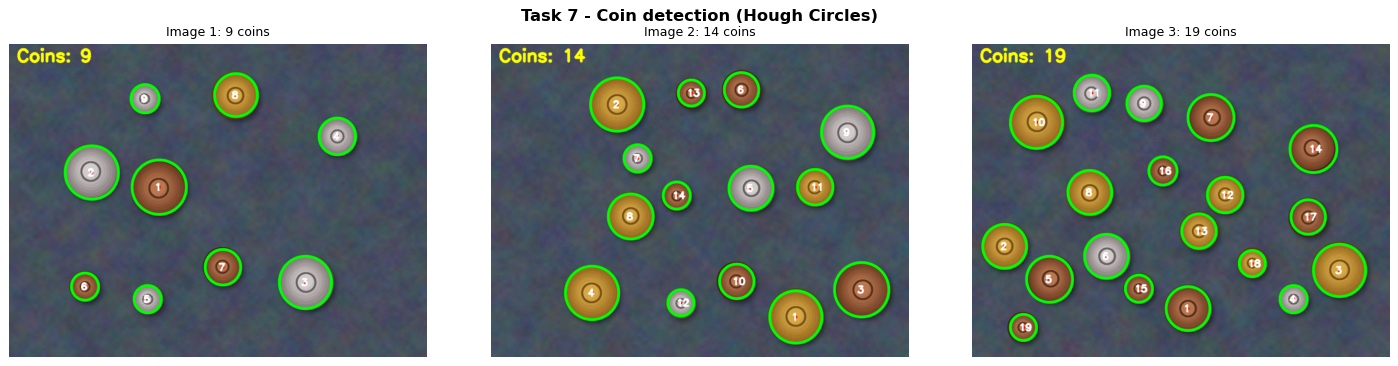

,Image,Detected,Expected,Size classes (radius: count)
0,1,9,9,"{'~26px': 3, '~34px': 2, '~41px': 1, '~51px': 3}"
1,2,14,14,"{'~26px': 4, '~33px': 3, '~42px': 2, '~51px': 5}"
2,3,19,19,"{'~26px': 5, '~33px': 5, '~43px': 7, '~50px': 2}"


In [9]:
COIN_PATHS = None           # e.g. ["coins1.jpg"]  (None -> synthetic coins)
MIN_R, MAX_R, PARAM2 = 24, 62, 35

def make_coin_image(n_coins, seed, w=800, h=600):
    r = np.random.default_rng(seed)
    bg = textured_background(w, h, seed=seed + 50, contrast=0.12, base=(95, 80, 70))
    radii = [28, 36, 44, 52]
    styles = [((70, 170, 215), (30, 100, 150)), ((205, 205, 210), (120, 120, 130)), ((80, 120, 185), (35, 60, 110))]  # gold, silver, copper
    coins, tries = [], 0
    while len(coins) < n_coins and tries < 5000:
        tries += 1
        R = int(r.choice(radii)); c = (int(r.integers(R + 15, w - R - 15)), int(r.integers(R + 15, h - R - 15)))
        if all(math.hypot(c[0] - o[0][0], c[1] - o[0][1]) > R + o[1] + 14 for o in coins):
            coins.append((c, R, styles[int(r.integers(0, 3))]))
    shadow = np.zeros((h, w), np.float32)
    for c, R, _ in coins:
        cv2.circle(shadow, (c[0] + 5, c[1] + 6), R, 1.0, -1)
    shadow = cv2.GaussianBlur(shadow, (0, 0), 5)
    img = (bg.astype(np.float32) * (1 - 0.5 * shadow[..., None])).astype(np.uint8)
    for c, R, (light, dark) in coins:
        for k in range(8):                                                # radial shading
            f = k / 7.0
            col = tuple(int(dark[j] * (1 - f) + light[j] * f) for j in range(3))
            cv2.circle(img, (c[0] - int(R * 0.06 * f), c[1] - int(R * 0.06 * f)), int(R * (1 - 0.1 * k)), col, -1, cv2.LINE_AA)
        cv2.circle(img, c, R, tuple(int(v * 0.6) for v in dark), 2, cv2.LINE_AA)
        cv2.circle(img, c, int(R * 0.35), tuple(int(v * 0.8) for v in dark), 2, cv2.LINE_AA)
    img = np.clip(img.astype(np.float32) + r.normal(0, 3, img.shape), 0, 255).astype(np.uint8)
    return img, len(coins)

def count_coins(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(gray, 5)
    circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=2 * MIN_R - 4,
                               param1=120, param2=PARAM2, minRadius=MIN_R, maxRadius=MAX_R)
    return [] if circles is None else np.round(circles[0]).astype(int)

if COIN_PATHS and all(os.path.exists(p) for p in COIN_PATHS):
    coin_imgs = [(cv2.imread(p), None) for p in COIN_PATHS]
else:
    coin_imgs = [make_coin_image(n_, seed=s_) for n_, s_ in ((9, 1), (14, 2), (19, 3))]
    for i, (im, _) in enumerate(coin_imgs, 1):
        cv2.imwrite(f"{IN_DIR}/task7_coins{i}.png", im)

vis7, rows7 = [], []
for i, (im, truth) in enumerate(coin_imgs, 1):
    circ = count_coins(im)
    v = im.copy()
    for j, (x, y, r_) in enumerate(circ, 1):
        cv2.circle(v, (x, y), r_, (0, 255, 0), 3, cv2.LINE_AA); cv2.circle(v, (x, y), 3, (0, 0, 255), -1)
        cv2.putText(v, str(j), (x - 8, y + 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(v, f"Coins: {len(circ)}", (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 255), 3, cv2.LINE_AA)
    vis7.append(v); cv2.imwrite(f"{OUT_DIR}/task7_coins_{i}.png", v)
    sizes = {}
    if len(circ):
        rad = circ[:, 2].astype(float)
        for g in cluster_1d(rad, 4):                                   # coins with similar radius = one size class
            sizes[f"~{rad[g].mean():.0f}px"] = len(g)
    rows7.append({"Image": i, "Detected": len(circ), "Expected": truth if truth is not None else "-",
                  "Size classes (radius: count)": sizes})

show_grid(vis7, [f"Image {i + 1}: {r_['Detected']} coins" for i, r_ in enumerate(rows7)], cols=3, size=(5.4, 4.1), suptitle="Task 7 - Coin detection (Hough Circles)")
display(pd.DataFrame(rows7))
if all(r_["Expected"] != "-" for r_ in rows7):
    ok7 = all(r_["Detected"] == r_["Expected"] for r_ in rows7)
    RESULTS.append(("7 Coin counting (Hough circles)", " / ".join(f"{r_['Detected']} of {r_['Expected']}" for r_ in rows7), ok7))
else:
    RESULTS.append(("7 Coin counting (Hough circles)", " / ".join(str(r_["Detected"]) for r_ in rows7) + " coins", True))

---
## Task 8 – Smart Security System (boundary detection + zone alarm)

**Goal:** in a (real-time) video stream, detect the **boundaries of objects** inside a predefined **security zone** and **trigger an alarm** when an unauthorised object enters it.

**Input needed:** a video from a fixed camera and the zone polygon. *Generated here:* 120-frame video (`task8_video.avi`): object **A** crosses the top of the scene *outside* the zone (must **not** alarm); object **B** (a bag) walks in, **enters the zone, stays, and leaves** (must alarm only while inside). *Your own data:* set `SECURITY_VIDEO_PATH` and edit `ZONE`.

**Method (per frame)**
1. **Background model:** median of the first 10 (empty) frames.
2. Grayscale + blur → `absdiff` with the background → threshold → morphological open/close → clean **foreground mask**.
3. **`cv2.findContours`** → object **boundaries**; ignore tiny blobs.
4. Zone test: overlap (pixels) between each object's filled contour and the **zone mask**; `≥ 250 px` → **ALARM**.
5. Draw boundaries (green = outside, red = in zone), the zone (turns red on alarm) and an **ALARM banner**; save the annotated video, log alarm frames, and play a beep.

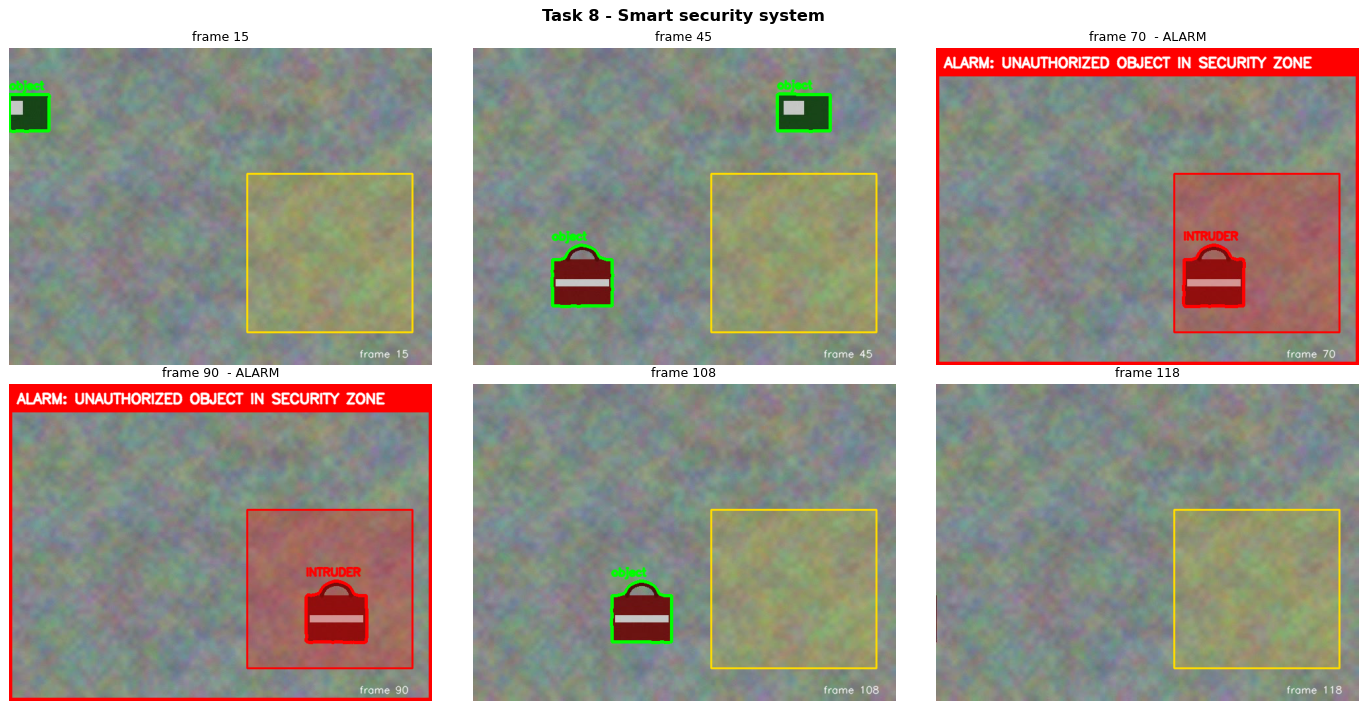

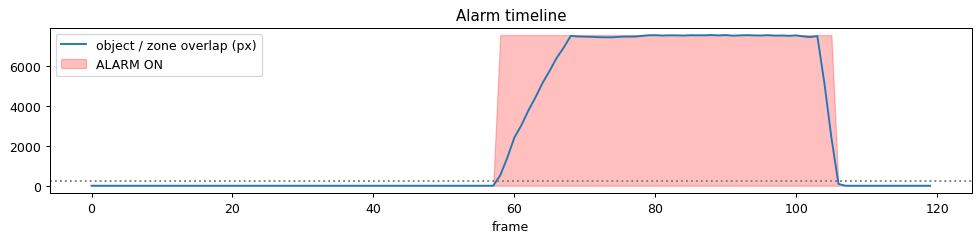

Alarm frames: 48 -> first at frame 58 (2.90s), last at frame 105
Agreement with ground-truth alarm state: 120/120 frames (100.0 %)
Annotated video saved -> lab06_outputs/task8_output.avi


In [10]:
SECURITY_VIDEO_PATH = None                                   # None -> synthetic video
ZONE = np.array([[360, 190], [610, 190], [610, 430], [360, 430]], np.int32)   # restricted area (x, y) polygon
W8, H8, N8, FPS8 = 640, 480, 120, 20
MIN_AREA, MIN_OVERLAP, BG_FRAMES, DIFF_T = 800, 250, 10, 28

zone_mask = np.zeros((H8, W8), np.uint8); cv2.fillPoly(zone_mask, [ZONE], 255)

if SECURITY_VIDEO_PATH and os.path.exists(SECURITY_VIDEO_PATH):
    frames8 = read_video(SECURITY_VIDEO_PATH); gt_alarm = None
    H8, W8 = frames8[0].shape[:2]
    zone_mask = np.zeros((H8, W8), np.uint8); cv2.fillPoly(zone_mask, [ZONE], 255)
else:
    bg8 = textured_background(W8, H8, seed=31, contrast=0.25, base=(135, 140, 130))
    rn8 = np.random.default_rng(8)
    xB = np.interp(np.arange(N8), [0, 25, 60, 80, 100, 119], [-120, -120, 300, 450, 450, -120])
    frames8, gt_alarm = [], []
    for k in range(N8):
        fr = bg8.copy(); mB = np.zeros((H8, W8), np.uint8)
        xa = int(np.interp(k, [10, 60], [-100, 700]))                       # object A: top lane, never in zone
        if 10 <= k <= 60:
            cv2.rectangle(fr, (xa, 70), (xa + 80, 125), (25, 70, 25), -1); cv2.rectangle(fr, (xa + 10, 80), (xa + 40, 100), (200, 200, 200), -1)
        if k >= 25:                                                         # object B: unauthorised bag
            xb = int(xB[k]); yb = 320
            cv2.rectangle(fr, (xb, yb), (xb + 90, yb + 70), (20, 20, 110), -1)
            cv2.ellipse(fr, (xb + 45, yb), (22, 18), 0, 180, 360, (15, 15, 80), 6)
            cv2.rectangle(fr, (xb + 5, yb + 30), (xb + 85, yb + 40), (200, 200, 200), -1)
            cv2.rectangle(mB, (xb, yb - 18), (xb + 90, yb + 70), 255, -1)
        gt_alarm.append(int(cv2.countNonZero(cv2.bitwise_and(mB, zone_mask)) >= MIN_OVERLAP))
        fr = np.clip(fr.astype(np.float32) + rn8.normal(0, 3, fr.shape), 0, 255).astype(np.uint8)
        frames8.append(fr)
    write_video(f"{IN_DIR}/task8_video.avi", frames8, FPS8)
    frames8 = read_video(f"{IN_DIR}/task8_video.avi", fallback=frames8)

# ---- 1. background model ----
bg_model = np.median(np.stack([cv2.GaussianBlur(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY), (5, 5), 0) for f in frames8[:BG_FRAMES]]), axis=0).astype(np.uint8)
k_open, k_close = np.ones((3, 3), np.uint8), cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

def analyse(frame):
    g = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    diff = cv2.absdiff(g, bg_model)
    _, fg = cv2.threshold(diff, DIFF_T, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k_open)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, k_close, iterations=2)
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    objs = []
    for c in cnts:
        if cv2.contourArea(c) < MIN_AREA: continue
        m = np.zeros(fg.shape, np.uint8); cv2.drawContours(m, [c], -1, 255, -1)
        objs.append((c, cv2.countNonZero(cv2.bitwise_and(m, zone_mask))))
    return fg, objs

out8, alarm_log, overlap_curve = [], [], []
for k, fr in enumerate(frames8):
    fg, objs = analyse(fr)
    alarm = any(ov >= MIN_OVERLAP for _, ov in objs)
    vis = fr.copy()
    zl = vis.copy(); cv2.fillPoly(zl, [ZONE], (0, 0, 255) if alarm else (0, 220, 255))
    vis = cv2.addWeighted(zl, 0.25 if alarm else 0.15, vis, 0.75 if alarm else 0.85, 0)
    cv2.polylines(vis, [ZONE], True, (0, 0, 255) if alarm else (0, 220, 255), 2)
    for c, ov in objs:
        inside = ov >= MIN_OVERLAP
        cv2.drawContours(vis, [c], -1, (0, 0, 255) if inside else (0, 255, 0), 3)
        x, y, w_, h_ = cv2.boundingRect(c)
        cv2.putText(vis, "INTRUDER" if inside else "object", (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255) if inside else (0, 255, 0), 2, cv2.LINE_AA)
    if alarm:
        cv2.rectangle(vis, (0, 0), (W8 - 1, H8 - 1), (0, 0, 255), 8)
        cv2.rectangle(vis, (0, 0), (W8, 42), (0, 0, 255), -1)
        cv2.putText(vis, "ALARM: UNAUTHORIZED OBJECT IN SECURITY ZONE", (12, 29), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(vis, f"frame {k}", (W8 - 110, H8 - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    out8.append(vis); alarm_log.append(int(alarm)); overlap_curve.append(max([ov for _, ov in objs], default=0))
write_video(f"{OUT_DIR}/task8_output.avi", out8, FPS8)

pick8 = [15, 45, 70, 90, 108, 118]
show_grid([out8[i] for i in pick8], [f"frame {i}" + ("  - ALARM" if alarm_log[i] else "") for i in pick8], cols=3, size=(5.2, 4),
          suptitle="Task 8 - Smart security system")
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(overlap_curve, label="object / zone overlap (px)"); ax.axhline(MIN_OVERLAP, color="gray", ls=":")
ax.fill_between(range(len(alarm_log)), 0, max(overlap_curve) * np.array(alarm_log), color="red", alpha=0.25, label="ALARM ON")
ax.set_xlabel("frame"); ax.legend(loc="upper left"); ax.set_title("Alarm timeline"); plt.tight_layout(); plt.show()

on = [i for i, a in enumerate(alarm_log) if a]
print(f"Alarm frames: {len(on)} -> " + (f"first at frame {on[0]} ({on[0] / FPS8:.2f}s), last at frame {on[-1]}" if on else "none"))
if gt_alarm is not None:
    agree = sum(int(a == g) for a, g in zip(alarm_log, gt_alarm)); acc8 = agree / len(gt_alarm)
    print(f"Agreement with ground-truth alarm state: {agree}/{len(gt_alarm)} frames ({100 * acc8:.1f} %)")
    RESULTS.append(("8 Smart security (zone alarm)", f"alarm state correct in {agree}/{len(gt_alarm)} frames", acc8 >= 0.95))
else:
    RESULTS.append(("8 Smart security (zone alarm)", f"{len(on)} alarm frames", True))
print("Annotated video saved ->", f"{OUT_DIR}/task8_output.avi")

sr = 22050; tt = np.linspace(0, 0.8, int(sr * 0.8), False)
beep = 0.4 * np.sin(2 * np.pi * 900 * tt) * (np.sin(2 * np.pi * 5 * tt) > 0)
display(Audio(beep, rate=sr))        # alarm sound (plays in Jupyter / Colab)

---
# Summary
All tasks are checked against the known ground truth of the generated inputs.

In [11]:
summary = pd.DataFrame(RESULTS, columns=["Task", "Result", "Passed"])
summary["Passed"] = summary["Passed"].map({True: "PASS", False: "CHECK"})
display(summary.style.hide(axis="index"))
print("\nInputs written to :", sorted(os.listdir(IN_DIR)))
print("Outputs written to:", sorted(os.listdir(OUT_DIR)))

Task,Result,Passed
1 Screen detection (Hough lines),"ON 5/5, OFF 2/2, missing 1/1",PASS
2 Asset tracking (SIFT),6/6 assets found,PASS
3 Wavelet anomaly detection,"recall 1.00, precision 1.00 (8 flagged)",PASS
4 Object recognition (SIFT video),"recall 80/80, false positives 0, centre err 0.1px",PASS
5 Panorama (SIFT stitching),5 images -> 1883x333 px,PASS
6 Lane detection (Hough lines),"both lanes in 3/3 images, max err 3 px",PASS
7 Coin counting (Hough circles),9 of 9 / 14 of 14 / 19 of 19,PASS
8 Smart security (zone alarm),alarm state correct in 120/120 frames,PASS



Inputs written to : ['task1_lab.png', 'task2_scene.png', 'task2_template_keyboard.png', 'task2_template_monitor.png', 'task2_template_mouse.png', 'task2_template_pc_tower.png', 'task3_sensor.csv', 'task4_reference.png', 'task4_video.avi', 'task5_pano_1.jpg', 'task5_pano_2.jpg', 'task5_pano_3.jpg', 'task5_pano_4.jpg', 'task5_pano_5.jpg', 'task6_road1.png', 'task6_road2.png', 'task6_road3.png', 'task7_coins1.png', 'task7_coins2.png', 'task7_coins3.png', 'task8_video.avi']
Outputs written to: ['task1_screens.png', 'task2_inventory.png', 'task3_wavelet_anomalies.png', 'task4_output.avi', 'task5_panorama.jpg', 'task6_lanes_1.png', 'task6_lanes_2.png', 'task6_lanes_3.png', 'task7_coins_1.png', 'task7_coins_2.png', 'task7_coins_3.png', 'task8_output.avi']


### How to plug in your own data
| Task | Variable(s) to set | What to provide |
|---|---|---|
| 1 | `LAB_IMAGE_PATH` | photo of the lab (rectangular screens, frontal view) |
| 2 | `TEMPLATE_PATHS`, `ASSET_SCENE_PATH` | `{"Monitor": "m.jpg", ...}` + one scene photo |
| 3 | `SENSOR_CSV` | CSV with one column of sensor values; tune `K` |
| 4 | `REF_IMAGE_PATH`, `OBJ_VIDEO_PATH` | reference photo + video |
| 5 | `PANO_PATHS` | ordered list of overlapping photos (left → right) |
| 6 | `LANE_PATHS` | list of dash-cam road images (adjust the ROI polygon if needed) |
| 7 | `COIN_PATHS`, `MIN_R`, `MAX_R`, `PARAM2` | coin photos; set radii in pixels |
| 8 | `SECURITY_VIDEO_PATH`, `ZONE` | fixed-camera video (first 10 frames empty) + zone polygon |